# Procesamiento del Lenguaje Natural
# Práctica 6: Análisis de Emociones y Sentimiento

Grupo 10:
- Prieto Maffla, Agustín
- Tejera Munguía, Violeta

## Ejercicio 1: Construye un dataset sintético de frases y emociones.

Comenzamos descargándonos el Word-Emotion Association Lexicon del NRC y trabajando con el fichero en castellano. Puesto que se trata de una práctica sobre *sentiment analysis*, hemos preprocesado el archivo para eliminar todas aquellas entradas referentes a palabras sin ninguna emoción asociada, como es el caso de "aback". El dataset ha pasado de tener $14154$ unigramas a $6453$, es decir, nos hemos quedado con el $\sim 45.6\%$ del dataset.

A su vez, hemos eliminado la columna con la traducción al castellano de los vocablos (No encontramos este archivo directamente en inglés, por eso hemos hecho este paso extra).

In [19]:
import pandas as pd

df = pd.read_csv("Spanish-NRC-EmoLex.txt", sep="\t")

emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
]

# Quitamos las palabras que no tienen asociada ninguna emoción
df = df[df[emotion_cols].sum(axis=1) > 0]

# Quitamos la columna con la palabra traducida al castellano
df = df[["English Word"] +emotion_cols]

df.head()
df.to_csv("FILTRADO-Spanish-NRC-EmoLex.txt", header=["English Word"]+emotion_cols, sep="\t")


GPT 5.4 Thinking
Prompt 1:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase en inglés con esa palabra, respetando las emociones de la fila y polarización (positive, negative), devuelveme un nuevo csv

Prompt 2:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv

Prompt 3:
Mensaje 1:
Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, tiene que ser una frase aleatoria que utilice dicha palabra de forma natural, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv no me sirve que hagas algo del estilo: Hearing ""abacus"" gave people a sense of reliability and trust., no tiene que ser una frase creativa donde se use en el contexto adecuado, no puedes usar una librería, las tienes que crear tú de forma natural, espero que lleve tiempo

Mensaje 2:
Hay mucha repeticion, las frases tienen que ser unicas, si quieres lo puedes ir generando por tandas y uniendolos, pero espero que demore mucho

Mensaje 3: 
Tienen que ser únicas y la palbra tiene que tenir sentido contextual en la frase, no simplmente que aparezca

Resultados Descartados

Con Gemini Model 3 Flash:

Prompt:

We are working with the following lexicon and wish to create a synthetic based on it with sentences that are tagged with different emotions (anger, anticipation,...) and their polarity (positive or negative). We want 1000 random sentences in English that use words from the lexicon in a natural way (Think of sentences that would be feasible to be found on a novel or in a conversation with another person). 

Claude Code Opus 4.6 Extended

Prompt 1:

Quiero que extiendas este dataset para agregar una columna nueva que se llame phrase que contenga una frase de ejemplo en inglés utilizando esa palabra, tiene que ser una frase aleatoria que utilice dicha palabra de forma natural, respetando las emociones de la fila y polarización (positive, negative) al crear la frase, devuelveme un nuevo csv no me sirve que hagas algo del estilo: Hearing ""abacus"" gave people a sense of reliability and trust., no tiene que ser una frase creativa donde se use en el contexto adecuado, no puedes usar una librería, las tienes que crear tú de forma natural, espero que lleve tiempo, no pueden ser generadas por un script, tienes que generarlas tú

Claude Code Opus 4.6

Prompt 2: 

Analiza si hay patrones evidentes

Claude Code Opus 4.6

Prompt 3:

Cambia solo los patrones que mayor ocurrencia tengan para darle más variabilidad

Resultados Seleccionados para posterior tratamiento

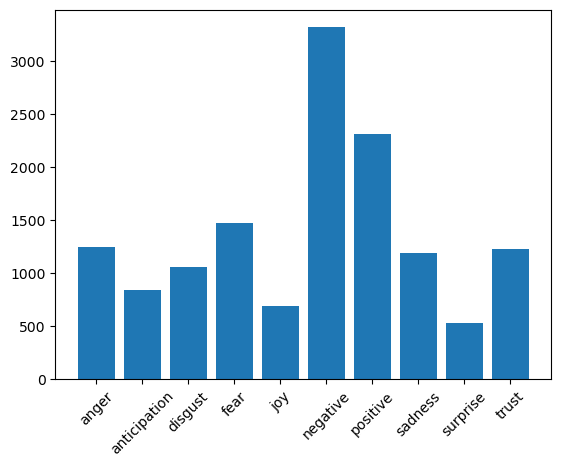

In [20]:
import matplotlib.pyplot as plt

label_counts = df[emotion_cols].sum(axis=0)

plt.figure()
plt.bar(emotion_cols, label_counts)
plt.xticks(rotation=45)
plt.show()

## Ejercicio 2: Tomando como entrada el dataset que acabas de construir en el apartado anterior:

### Selecciona y entrena al menos 2 algoritmos de aprendizaje automático no basados en redes neuronales para clasificar emociones. Explica por qué has decidido seleccionar esos modelos.

En el anterior ejercicio construimos un dataset sintético de frases cortas utilizando diferentes palabras del Word-Emotion Association Lexicon del National Research Council, etiquetadas con diversas emociones y su polaridad. Un mismo término puede tener asociadas más de una emoción, por lo que nos encontramos ante un problema de clasificación multietiqueta (sobre textos cortos).

Uno de los algoritmos que vamos a probar es la Regresión Logística, porque hace una buena combinación con TF-IDF (Term Frequency - Inverse Document Frequency, lo discutiremos en más profundidad más adelante en este ejercicio) y los n-gramas de palabra o de caracteres.

El otro que hemos seleccionado es el SGDClassifier, porque nuestro dataset, al contar con casi 6500 patrones, es considerablemente grande. Utilizaremos la función de pérdida _hinge_ para que se comporte como una SVM lineal, porque tenemos un espacio altamente dimensional.

Antes de entrenar el modelo, necesitamos definir algunos criterios más, planteados por otros apartados de esta pregunta, por lo que vamos a responderlos a todos antes de dedicarnos a entrenar.

### Señala cuál ha sido tu política para la construcción de conjuntos de entrenamiento, validación y test.

Se ha dividido el dataset de la siguiente manera: 70% se destinará al entrenamiento de los modelos, 15% para validarlos y el 15% para su test. La división se hará de manera aleatoria e intentando mantener la distribución de etiquetas en los distintos subconjuntos.

### Identifica al menos 2 modelos de vectorización del texto diferentes con los que entrenar cada algoritmo elegido. Pueden ser vectores dispersos o densos. Justifica por qué has elegido esos modelos y no otros.

Hemos elegido comparar Bag of Words, que representa vectoriza los documentos basándose en la frecuencia de vocablos; con TF-IDF, que lo hace evaluando la importancia de las diversas palabras del documento. Se configurarán con tanto unigramas como bigramas para capturar no sólo la presencia individual de palabras, sino también pequeñas estructuras contextuales de las mismas, como puede ser la negación ("not good") de éstas.

### Usa las métricas más adecuadas que te permitan analizar la eficacia de los modelos. Contrasta los valores obtenidos.

Como nuestro problema es multietiqueta, no deberíamos utilizar _Accuracy_, que es una métrica bastante clásica. _Precision_ (Proporción de predicciones correctas sobre todas las predicciones de una misma clase) y _Recall_ (Proporción de ejemplos de una misma clase que han sido clasificados correctamente) son métricas más robustas.

$$
\text{Precision} = \frac{\text{True Positive}}{\text{False Positive}+\text{True Positive}}
$$

$$
\text{Recall} = \frac{\text{True Positive}}{\text{False Negative}+\text{True Positive}}
$$

Sin embargo, al estar ser un problema de clasificación multietiqueta, utilizaremos el _F1-Score_, que combina a las dos anteriores mediante la media armónica, para penalizar grandes diferencias entre ambas y así luchar contra el desbalanceo del dataset.

$$
F_1 = 2 \cdot \frac{\text{Precision}\cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

También utilizaremos la _Hamming Loss_, que es la fracción de etiquetas que han sido predichas de manera incorrecta.

-------

Ahora podemos proceder a resolver el ejercicio. Empezamos por la división del dataset en conjuntos de _train_, _validation_ y _test_.

In [21]:
import pandas as pd
from skmultilearn.model_selection import iterative_train_test_split

df = pd.read_csv("data.tsv", sep="\t")

emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
]

X = df["phrase"].to_numpy().reshape(-1, 1)
y = df[emotion_cols].to_numpy()

X_train, y_train, X_temp, y_temp = iterative_train_test_split(
    X, y, test_size=0.3
)

X_val, y_val, X_test, y_test = iterative_train_test_split(
    X_temp, y_temp, test_size=0.5
)

X_train = X_train.ravel()
X_val = X_val.ravel()
X_test = X_test.ravel()

A continuación, realizamos las distintas vectorizaciones sobre los datos de entrenamiento:

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow = CountVectorizer(ngram_range=(1,2))
tfidf = TfidfVectorizer(ngram_range=(1,2))

X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)
X_test_bow = bow.transform(X_test)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

Ahora vamos a realizar un estudio de los hiperparámetros para cada combinación de modelo clasificador y modelo de vectorización.

In [23]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm

#### Regresión Logística

In [24]:
best_score_reglog_bow = 0
best_model_reglog_bow = None
best_C_reglog_bow = None

for C in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(LogisticRegression(C=C, class_weight="balanced"))
    model.fit(X_train_bow, y_train)

    score = f1_score(y_val, model.predict(X_val_bow), average="micro")

    if score > best_score_reglog_bow:
        best_score_reglog_bow = score
        best_model_reglog_bow = model
        best_C_reglog_bow = C

print(f"Best C: {best_C_reglog_bow} - Val. Score: {best_score_reglog_bow}")

100%|██████████| 4/4 [00:11<00:00,  2.89s/it]

Best C: 0.01 - Val. Score: 0.38893653516295024


In [25]:
best_score_reglog_tfidf = 0
best_model_reglog_tfidf = None
best_C_reglog_tfidf = None

for C in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(LogisticRegression(C=C, class_weight="balanced"))
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_reglog_tfidf:
        best_score_reglog_tfidf = score
        best_model_reglog_tfidf = model
        best_C_reglog_tfidf = C

print(f"Best C: {best_C_reglog_tfidf} - Val. Score: {best_score_reglog_tfidf}")

100%|██████████| 4/4 [00:03<00:00,  1.06it/s]

Best C: 0.01 - Val. Score: 0.4034543844109832


#### SGD

In [26]:
best_score_sgd_bow = 0
best_model_sgd_bow = None
best_alpha_sgd_bow = None

for alpha in tqdm([0.01, 0.1, 1, 10]):
    model = OneVsRestClassifier(SGDClassifier(loss="hinge", alpha=alpha, class_weight="balanced"))
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_val_bow)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_sgd_bow:
        best_score_sgd_bow = score
        best_model_sgd_bow = model
        best_alpha_sgd_bow = alpha

print(f"Best alpha: {best_alpha_sgd_bow} - Val. Score: {best_score_sgd_bow}")

100%|██████████| 4/4 [00:00<00:00,  6.88it/s]

Best alpha: 0.01 - Val. Score: 0.4014352993944831


In [27]:
best_score_sgd_tfidf = 0
best_model_sgd_tfidf = None
best_alpha_sgd_tfidf = None

for alpha in tqdm([0.0001, 0.001, 0.01]):
    model = OneVsRestClassifier(SGDClassifier(loss="hinge", alpha=alpha, class_weight="balanced"))
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)

    score = f1_score(y_val, preds, average="micro")

    if score > best_score_sgd_tfidf:
        best_score_sgd_tfidf = score
        best_model_sgd_tfidf = model
        best_alpha_sgd_tfidf = alpha

print(f"Best alpha: {best_alpha_sgd_tfidf} - Val. Score: {best_score_sgd_tfidf}")

100%|██████████| 3/3 [00:00<00:00,  8.82it/s]

Best alpha: 0.001 - Val. Score: 0.4078398665554629


Ahora ya tenemos los mejores modelos de cada tipo, procedemos a compararlos sobre los datos de test:

In [28]:
from sklearn.metrics import hamming_loss

In [29]:
models_bow = {
    "RegLog - BoW": best_model_reglog_bow,    
    "SGD - BoW": best_model_sgd_bow
}

models_tfidf = {
    "RegLog - TFIDF": best_model_reglog_tfidf,    
    "SGD - TFIDF": best_model_sgd_tfidf,    
}

models_metrics = {}

def calculate_metrics(y_test, preds):
    f1_micro = f1_score(y_test, preds, average="micro")
    f1_macro = f1_score(y_test, preds, average="macro")
    hamming = hamming_loss(y_test, preds)

    return f1_micro, f1_macro, hamming

for model_name, model in models_bow.items():
    preds = model.predict(X_test_bow)
    models_metrics[model_name] = (calculate_metrics(y_test, preds))

for model_name, model in models_tfidf.items():
    preds = model.predict(X_test_tfidf)
    models_metrics[model_name] = (calculate_metrics(y_test, preds))

models_metrics

{'RegLog - BoW': (0.3906817696088908, 0.3272629857772009, 0.3010559662090813),
 'SGD - BoW': (0.4067495559502664, 0.32823637997654165, 0.28215417106652585),
 'RegLog - TFIDF': (0.4101321585903084,
  0.3351414299412256,
  0.28278775079197466),
 'SGD - TFIDF': (0.41228070175438597, 0.3422843273622991, 0.29714889123548044)}

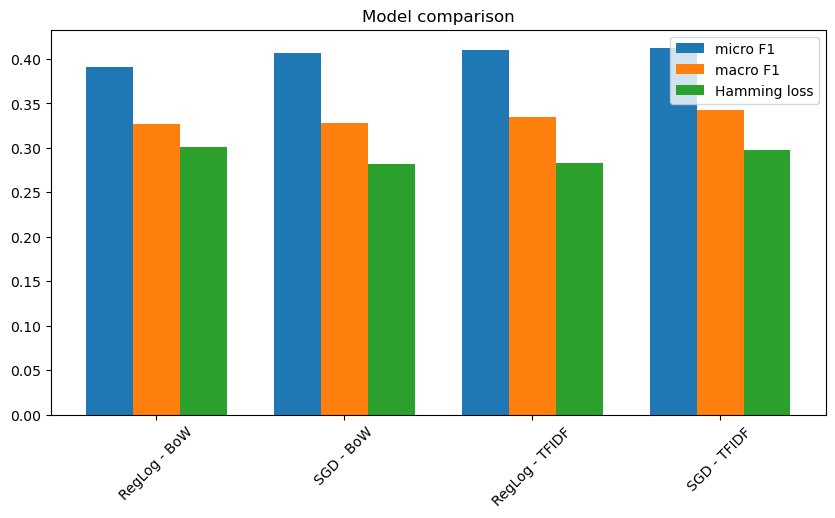

Best micro F1 : 0.4123 -> SGD - TFIDF
Best macro F1: 0.3423 -> SGD - TFIDF
Best Hamming loss: 0.2822 -> SGD - BoW


In [30]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(models_metrics.keys())
values = np.array(list(models_metrics.values()))

f1_micro = values[:, 0]
f1_macro = values[:, 1]
hamming = values[:, 2]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, f1_micro, width, label="micro F1")
plt.bar(x, f1_macro, width, label="macro F1")
plt.bar(x + width, hamming, width, label="Hamming loss")

plt.xticks(x, labels, rotation=45)
plt.title("Model comparison")
plt.legend()
plt.show()

best_micro_idx = np.argmax(f1_micro)
best_macro_idx = np.argmax(f1_macro)
best_hamming_idx = np.argmin(hamming)

print(f"Best micro F1 : {f1_micro[best_micro_idx]:.4f} -> {labels[best_micro_idx]}")
print(f"Best macro F1: {f1_macro[best_macro_idx]:.4f} -> {labels[best_macro_idx]}")
print(f"Best Hamming loss: {hamming[best_hamming_idx]:.4f} -> {labels[best_hamming_idx]}")

A la luz de los resultados, observamos que los modelos presentan un rendimiento muy similar en todas las métricas. En general, la mejor configuración ha sido utilizar SGD y BoW, tanto desde el punto del rendimiento global (micro F1) como de cara al equilibrio entre etiquetas (macro F1). 

Todos los modelos obtienen valores bastante similares de Hamming Loss, lo que parece indicar un comportamiento homogéneo en cuanto al nivel de error por etiqueta el cual, a pesar de haber corregido el desbalance de clases mediante el parámetro "class_weight" durante el entrenamiento, sigue siendo considerablemente alto lo cual, en conjunción con la similitud de resultados entre modelos, parece indicar que no se trata de un problema de elección de clasificadores o vectorizadores; sino que la dificultad proviene de la naturaleza sintética del dataset y la propia complejidad de la clasificación multietiqueta de las emociones.

### Una vez entrenados, validados y evaluados los modelos, implementa la funcionalidad para guardarlos de forma local y poder recuperarlos más tarde.

In [31]:
import joblib

path = "./models/"

joblib.dump(best_model_reglog_bow, path+"model_reglog_bow.pkl")
joblib.dump(best_model_sgd_bow, path+"model_sgd_bow.pkl")
joblib.dump(best_model_reglog_tfidf, path+"model_reglog_tfidf.pkl")
joblib.dump(best_model_sgd_tfidf, path+"model_sgd_tfidf.pkl")
joblib.dump(bow, path+"vectorizer_bow.pkl")
joblib.dump(tfidf, path+"vectorizer_tfidf.pkl")

['./models/vectorizer_tfidf.pkl']

## Ejercicio 3: Implementa una función que permita analizar texto y proporcionar emociones vinculadasa él. Esta función debe:

- Recibir el texto a analizar, y uno de los algoritmos que has entrenado en apartados anteriores.

- Devolver, un diccionario donde las claves sean emociones del NRC y vinculadas con cada clave, el nivel de emoción que ha identificado. ¿Qué estrategia has empleado para decidir el nivel de cada emoción en el texto completo?

In [32]:
from typing import Literal

def analyze_emotions(text: str, model_path: str, model: Literal["sgd", "reglog"], vectorizer: Literal["bow", "tfidf"]):
    model_obj = joblib.load(f"{model_path}/model_{model}_{vectorizer}.pkl")
    vectorizer_obj = joblib.load(f"{model_path}/vectorizer_{vectorizer}.pkl")

    emotion_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "negative", "positive", "sadness", "surprise",
    "trust"
    ]

    X = vectorizer_obj.transform([text])
    probs = model_obj.decision_function(X)

    emotions = {}
    for i, emotion in enumerate(emotion_cols):
        emotions[emotion] = float(probs[0][i])

    return emotions

Se ha implementado una función que, dado un texto y unas configuraciones (clasificador-vectorizador), carga la opción elegida de modelo de entre los entrenados en el ejercicio anterior y analiza la intensidad de cada emoción.

Hemos abordado el problema desde una perspectiva probabilística, utilizando las probabilidades generadas por los clasificadores, que muestran el grado de confianza del modelo respecto a cada clase dentro del esquema One-vs-Rest; puesto que el léxico utilizado, EmoLex, simplemente utiliza una codificación binaria de las 8 emociones básicas de Plutchik para cada uno de los vocablos que contempla.

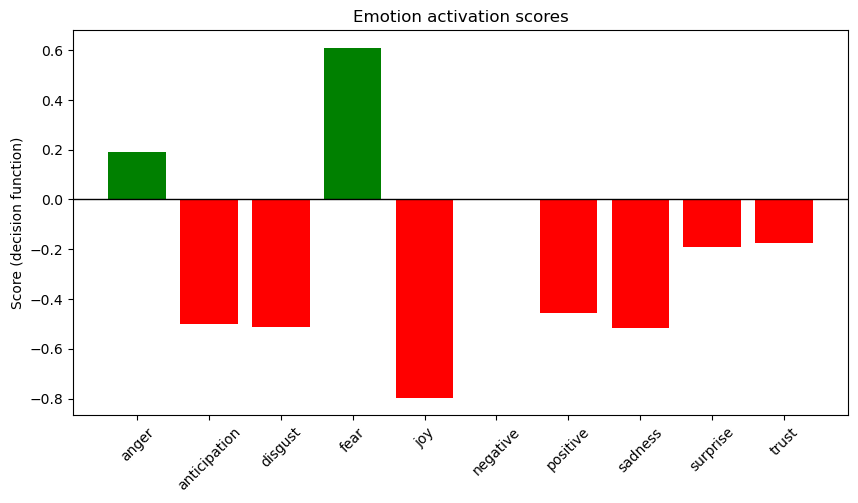

The quick brown fox jumps over the lazy dog.
{'anger': 0.188948055628003, 'anticipation': -0.5023649793715256, 'disgust': -0.5116191289223248, 'fear': 0.610104897375523, 'joy': -0.7963828593992357, 'negative': -0.0019485374789785792, 'positive': -0.45532966991844076, 'sadness': -0.5169595310285435, 'surprise': -0.18933653905102865, 'trust': -0.17301399545982024}


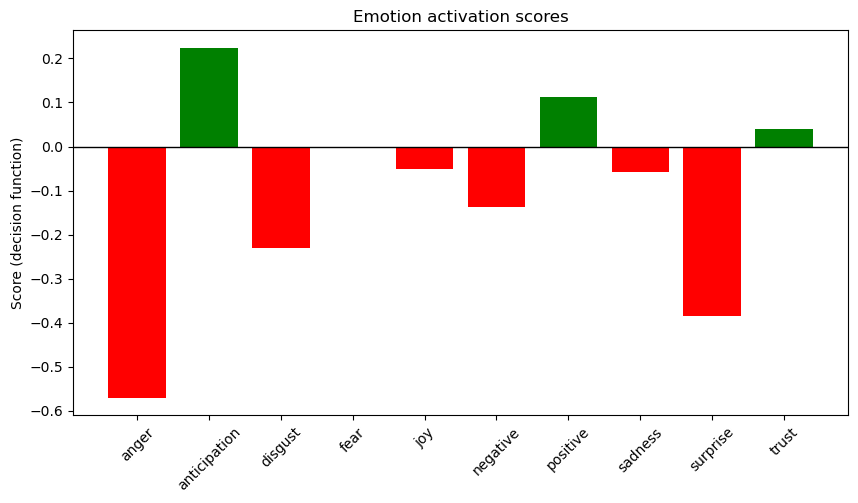

Today's weather is very sunny.
{'anger': -0.5702870014637863, 'anticipation': 0.22455868944117893, 'disgust': -0.22998324796126773, 'fear': -0.00017919963951642387, 'joy': -0.05029410143241751, 'negative': -0.13840812014293477, 'positive': 0.11226106807748144, 'sadness': -0.05871909466782431, 'surprise': -0.3858447485579751, 'trust': 0.03938166555944694}


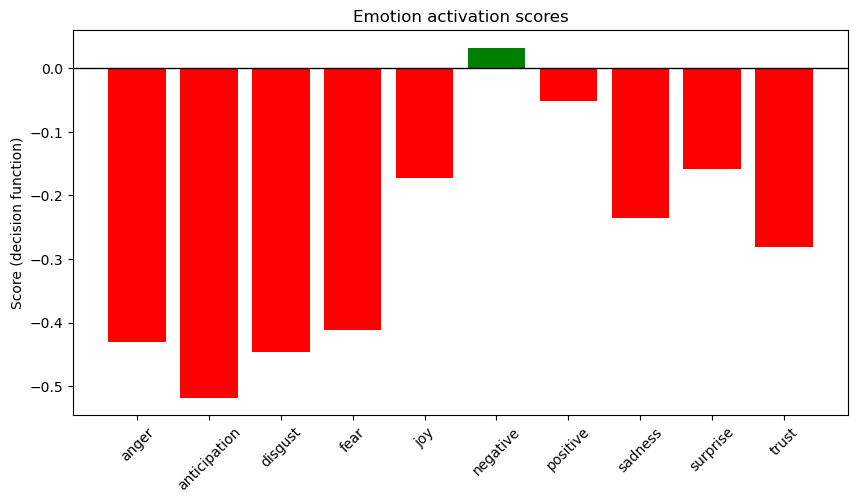

Yesterday was a rainy day and the children couldn't play outside.
{'anger': -0.43085954381938674, 'anticipation': -0.5177849197596675, 'disgust': -0.446563839285542, 'fear': -0.41129028925337513, 'joy': -0.1724857017063396, 'negative': 0.03238278556341674, 'positive': -0.050840467530074665, 'sadness': -0.23496661915757602, 'surprise': -0.15913824792667478, 'trust': -0.28123063309958546}


In [33]:
texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Today's weather is very sunny.",
    "Yesterday was a rainy day and the children couldn't play outside."
]

for text in texts:

    result = analyze_emotions(text, "./models", "sgd", "bow")

    plt.figure(figsize=(10,5))

    colors = ["green" if v >= 0 else "red" for v in result.values()]

    plt.bar(result.keys(), result.values(), color=colors)

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=45)
    plt.title("Emotion activation scores")
    plt.ylabel("Score (decision function)")
    plt.show()

    print(text)
    print(result)

Hemos probado la función con tres frases distintas. En la primera de ellas, el modelo ve fuerte presencia de las emociones negativas, de ira y de miedo; y duda mucho de otras emociones como puede ser la alegría.

En la segunda oración, se encuentra bastante neutral con la posible presencia de miedo; y, por ejemplo, ve una fuerte presencia de anticipación a la vez que una fuerte ausencia de ira.

En la última, sin embargo, percibe una ausencia fuerte para la mayoría de las emociones, aunque para algunas está más indeciso y para la polaridad negativa, ve una presencia fuerte.

Sin embargo, no deberíamos interpretar estos resultados como una detección literal de emociones, sino como la activación del modelo ante patrones lingüísticos similares a los que fueron observados durante su entrenamiento; sobretodo teniendo en cuenta las limitaciones previamente descritas con el proceso de análisis de intensidad y en el ejercicio anterior con el entrenamiento de los modelos.



## Ejercicio 4: Cargar el texto de novelas clásicas disponibles en Project Gutenberg.

El ejercicio comienza con la descarga de los libros seleccionados. Para cada obra, se incorporó un marcador que indica el inicio del texto relevante, con el fin de omitir elementos que no forman parte del contenido principal, como índices, prefacios u otros textos preliminares.

In [58]:
import requests

books = [
  ('Crime and Punishment', 'http://www.gutenberg.org/files/2554/2554-0.txt', 'On an exceptionally hot evening early'),
  ('War and Peace', 'http://www.gutenberg.org/files/2600/2600-0.txt', 'Well, Prince, so Genoa and Lucca are now just family'),
  ('Pride and Prejudice', 'http://www.gutenberg.org/files/1342/1342-0.txt', 'It is a truth universally acknowledged, that a single man in possession'),
  ('Frankenstein', 'https://www.gutenberg.org/cache/epub/84/pg84.txt', '_To Mrs. Saville, England._'),
  ('The Adventures of Sherlock Holmes', 'http://www.gutenberg.org/files/1661/1661-0.txt', 'To Sherlock Holmes she is always _the_ woman.'),
  ('Ulysses', 'http://www.gutenberg.org/files/4300/4300-0.txt', 'Stately, plump Buck Mulligan came from the stairhead,'),
  ('The Odyssey', 'https://www.gutenberg.org/cache/epub/1727/pg1727.txt', 'THE GODS IN COUNCIL—MINERVA'),
  ('Moby Dick', 'http://www.gutenberg.org/files/15/15-0.txt', 'Call me Ishmael. Some years ago—never mind how long'),
  ('The Divine Comedy', 'https://www.gutenberg.org/cache/epub/8800/pg8800.txt', 'In the midway of this our mortal life,'),
  ('Critias', 'https://www.gutenberg.org/cache/epub/1571/pg1571.txt', 'The Critias is a fragment which breaks off in the middle of a sentence.'),
]

from pathlib import Path

books_dir = Path("./books")

def get_book_path(title):
    return books_dir / f"{title.replace(' ', '_')}.txt"

def download_text(title, url):
  """Descarga el texto de una novela en formato txt."""
  try:
    response = requests.get(url, timeout=30)
    response.raise_for_status() # Lanza excepción para códigos HTTP 4xx/5xx

    out_path = get_book_path(title)
    out_path.write_text(response.text, encoding="utf-8")
    return out_path
  except requests.exceptions.RequestException as e:
    print(f"Error al descargar el texto: {e}")
    return None

for (title, url, start_phrase) in books:
  download_text(title, url)

### Procesamiento

El procesamiento de los datos se realizó de la siguiente manera: para cada novela, se identificó manualmente una frase o marcador de inicio, revisando las fuentes originales para garantizar que el análisis comenzara en el punto adecuado del texto. Como marca de finalización, se utilizó "END OF THE PROJECT GUTENBERG BOOK", presente en todas las novelas y que ayuda a omitir contenido irrelevante que aparece después del texto principal.

La segmentación del texto se llevó a cabo utilizando los saltos de línea como delimitadores. Si bien esta elección es debatible —pues la eficacia de los saltos de línea para separar unidades semánticas puede variar según el libro y el estilo de escritura—, para los fines de este trabajo resultó una opción razonable. Otra alternativa hubiera sido dividir por puntuación, pero se optó por la simplicidad de los saltos de línea.
 
Por último, se filtraron aquellas líneas que, al separar por espacios, tuvieran al menos 5 elementos (palabras, signos, etc.). Esta decisión busca evitar procesar textos demasiado breves, como títulos de capítulos o frases aisladas sin contexto suficiente para un análisis de sentimientos. Si bien esto podría excluir expresiones cortas cargadas de emoción, como "te odio", en líneas generales permite mantener el corpus limpio y relevante —especialmente considerando que contamos con novelas extensas. Además, los modelos empleados fueron entrenados con frases de cierta longitud, por lo que este filtrado resulta coherente con el modo en que esperan recibir los datos.

In [ ]:
import re

# solo se toman 5 novelas de las 10 disponibles
downloaded_books = books[:5]
processed_books = {}

for (title, url, start_phrase) in downloaded_books:
    text = get_book_path(title).read_text(encoding="utf-8")

    # regex para encontrar el bloque entre start_phrase y book_end y recortar todo lo demás
    book_end = r"\*\*\*\s*END OF (THE )?PROJECT GUTENBERG EBOOK.*?\*\*\*"
    pattern = rf"{re.escape(start_phrase)}(.*?){book_end}"
    match = re.search(pattern, text, flags=re.DOTALL | re.IGNORECASE)
    if match:
        # solo el contenido entre start_phrase y justo antes de book_end, sin incluir book_end
        main_text = start_phrase + match.group(1)
    else:
        print(f"No se pudo extraer correctamente el texto principal para {title}")
        main_text = text  # fallback: deja el texto completo

    lines = main_text.strip().splitlines()

    # agregada condicion para que no se procesen lineas demasiado cortas 
    # evita lineas mal procesads y cortas sin contexto suficiente, además el modelo fue entrenado con frases mas largas
    processed_books[title] = [line for line in lines if line.strip() and len(line.strip().split(' ')) >= 5]

print(processed_books["Pride and Prejudice"][:5])


['It is a truth universally acknowledged, that a single man in possession', 'of a good fortune must be in want of a wife.', 'However little known the feelings or views of such a man may be on his', 'first entering a neighbourhood, this truth is so well fixed in the minds', 'of the surrounding families, that he is considered as the rightful']


### Análisis

Se priorizó la métrica Micro porque el objetivo principal del análisis era obtener una visión global del perfil emocional de las novelas y comparar tendencias generales entre obras. Dado que se trata de un problema multietiqueta con clases desbalanceadas, la métrica Micro permite resumir el rendimiento total del modelo sobre el conjunto completo de predicciones. Sin embargo, esta métrica está más influida por las emociones más frecuentes, por lo que corremos el riesgo de observar patrones en sentimientos menos frecuentes.

In [192]:
model_chosen = "sgd"
vectorizer_chosen = "tfidf"

analyzed_books = {}
for book in processed_books:
    processed_book = processed_books[book]
    for line in processed_book:
        analyzed_books.setdefault(book, []).append(analyze_emotions(line, "./models", model_chosen, vectorizer_chosen))
   
print(analyzed_books["Pride and Prejudice"][:5])

[{'anger': -0.11585130409088398, 'anticipation': -0.5181372447620316, 'disgust': 0.6868795773442634, 'fear': -0.1113017448625638, 'joy': -0.6756623136642156, 'negative': 0.2127055824380875, 'positive': -0.03827067136169941, 'sadness': -0.3003591791320764, 'surprise': -1.1901129923168825, 'trust': 0.008330365838284788}, {'anger': -0.09175398452135035, 'anticipation': 0.3259439972750088, 'disgust': 0.08189204320764451, 'fear': -0.04006546616734157, 'joy': -0.28592895926303374, 'negative': -0.17810207382145632, 'positive': 0.13123833642206323, 'sadness': -0.265937437723582, 'surprise': -0.5270362139428751, 'trust': -0.060330474754251226}, {'anger': 0.24455232236029495, 'anticipation': -0.6285260056317014, 'disgust': -0.04934969653586138, 'fear': 0.09145816025878059, 'joy': -0.789143935060663, 'negative': 0.39440281779420316, 'positive': -0.5092525566259686, 'sadness': -0.29211445995905794, 'surprise': -0.6969783814881043, 'trust': -0.6808200619972237}, {'anger': -0.6503991061642421, 'anti

In [193]:
joblib.dump(analyzed_books, "./analysis/analyzed_books.pkl")

['./analysis/analyzed_books.pkl']

A continuación, se construye un diccionario que reúne las métricas principales de cada novela para facilitar el análisis posterior. Para cada emoción se calculan estadísticas descriptivas como la media, la desviación estándar, el valor mínimo y el máximo. Además, se incorpora la tasa de activación, definida como la proporción de fragmentos en los que el score de una emoción es mayor que cero, ya que esta será la métrica principal para interpretar la presencia relativa de cada emoción en las obras. También se calcula el percentil 90, con el fin de identificar valores altos y observar mejor los picos emocionales sin depender únicamente del máximo, que puede estar afectado por casos aislados. Finalmente, se añade la media de los scores positivos, lo que permite estimar la intensidad media de una emoción cuando efectivamente se activa.

In [195]:
books_data = joblib.load("./analysis/analyzed_books.pkl")

books_stats = {}

for book, emotion_dicts in books_data.items():
    emotion_matrix = np.array(
        [[d[emotion] for emotion in emotion_cols] for d in emotion_dicts],
        dtype=float
    )

    mean_scores = emotion_matrix.mean(axis=0)
    std_scores = emotion_matrix.std(axis=0)
    min_scores = emotion_matrix.min(axis=0)
    max_scores = emotion_matrix.max(axis=0)
    activation_rates = (emotion_matrix > 0).mean(axis=0)
    p90_scores = np.percentile(emotion_matrix, 90, axis=0)

    mean_positive_scores = np.array([
        emotion_matrix[emotion_matrix[:, i] > 0, i].mean()
        if np.any(emotion_matrix[:, i] > 0)
        else np.nan
        for i in range(emotion_matrix.shape[1])
    ])

    books_stats[book] = {
        "mean": dict(zip(emotion_cols, mean_scores)),
        "std": dict(zip(emotion_cols, std_scores)),
        "min": dict(zip(emotion_cols, min_scores)),
        "max": dict(zip(emotion_cols, max_scores)),
        "activation_rate": dict(zip(emotion_cols, activation_rates)),
        "mean_positive": dict(zip(emotion_cols, mean_positive_scores)),
        "p90": dict(zip(emotion_cols, p90_scores)),
        "num_lines": emotion_matrix.shape[0],
    }

print(books_stats)

{'Crime and Punishment': {'mean': {'anger': np.float64(-0.070751053596507), 'anticipation': np.float64(-0.4332862253885332), 'disgust': np.float64(-0.18907562811434023), 'fear': np.float64(-0.1796557540198448), 'joy': np.float64(-0.5292029163649766), 'negative': np.float64(0.13846625668916274), 'positive': np.float64(-0.14843602071641693), 'sadness': np.float64(-0.1343825237138763), 'surprise': np.float64(-0.603208180329103), 'trust': np.float64(-0.20577610800005958)}, 'std': {'anger': np.float64(0.36412181962250684), 'anticipation': np.float64(0.31312420459057594), 'disgust': np.float64(0.41239738664527564), 'fear': np.float64(0.3695581362509065), 'joy': np.float64(0.40268273835400187), 'negative': np.float64(0.4233501872210664), 'positive': np.float64(0.4322958407686718), 'sadness': np.float64(0.3810520981604897), 'surprise': np.float64(0.349267645011377), 'trust': np.float64(0.3992894604896362)}, 'min': {'anger': np.float64(-1.656727368346519), 'anticipation': np.float64(-1.58459980

## Ejercicio 5: Presenta los resultados del análisis en las novelas clásicas.

### Visualización inicial

Para facilitar la visualización y la comparación entre novelas, se creó un dataframe resumen con las métricas calculadas previamente. Cada fila corresponde a una novela y cada columna a una medida asociada a una emoción o polaridad.

Se separaron las variables de polaridad (positive, negative) de las emociones específicas, ya que no resulta adecuado analizarlas conjuntamente. Además, para cada novela se identificó la polaridad dominante.

En el dataframe se incluyeron, para cada emoción, la media, la desviación estándar, el mínimo, el máximo, la tasa de activación, la media de los scores positivos y el percentil 90, con el fin de facilitar el análisis comparativo posterior.

In [196]:
summary_rows = []

# separar datos de cada libro en polaridad y emociones
sentiment_cols = ["positive", "negative"]
emotion_only_cols = [e for e in emotion_cols if e not in sentiment_cols]

for book, stats in books_stats.items():
    row = {
        "book": book,
        "num_lines": stats["num_lines"],
        "dominant_polarity": max(
            sentiment_cols,
            key=lambda e: stats["mean"][e]
        )
    }

    for emotion in emotion_cols:
        row[f"{emotion}_mean"] = stats["mean"][emotion]
        row[f"{emotion}_std"] = stats["std"][emotion]
        row[f"{emotion}_min"] = stats["min"][emotion]
        row[f"{emotion}_max"] = stats["max"][emotion]
        row[f"{emotion}_activation_rate"] = stats["activation_rate"][emotion]
        row[f"{emotion}_mean_positive"] = stats["mean_positive"][emotion]
        row[f"{emotion}_p90"] = stats["p90"][emotion]

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

,book,num_lines,dominant_polarity,anger_mean,anger_std,anger_min,anger_max,anger_activation_rate,anger_mean_positive,anger_p90,...,surprise_activation_rate,surprise_mean_positive,surprise_p90,trust_mean,trust_std,trust_min,trust_max,trust_activation_rate,trust_mean_positive,trust_p90
0,Crime and Punishment,16510,negative,-0.070751,0.364122,-1.656727,1.593632,0.418413,0.264537,0.388463,...,0.045366,0.180711,-0.151681,-0.205776,0.399289,-1.706181,1.541732,0.300969,0.255735,0.303446
1,War and Peace,47135,negative,-0.050597,0.371158,-2.047034,1.744958,0.438252,0.280740,0.424193,...,0.069269,0.192195,-0.079725,-0.240108,0.389207,-2.028011,2.050867,0.261037,0.244184,0.255978
2,Pride and Prejudice,10080,negative,-0.126048,0.371002,-1.863853,1.527730,0.353472,0.262509,0.348517,...,0.041369,0.179888,-0.178249,-0.174947,0.390532,-1.515101,1.491949,0.323909,0.254382,0.319320
3,Frankenstein,6088,negative,-0.099972,0.332750,-1.312031,1.456908,0.366294,0.240919,0.326077,...,0.073587,0.182999,-0.063943,-0.209764,0.374631,-1.715959,1.730567,0.281537,0.237330,0.260442
4,The Adventures of Sherlock Holmes,8387,negative,-0.070038,0.343416,-1.707103,1.504509,0.403720,0.257172,0.364029,...,0.059855,0.191735,-0.109034,-0.243499,0.374148,-1.615150,1.405420,0.253130,0.228786,0.236441


### Emociones dominantes por novela

Con el fin de identificar las emociones predominantes en cada novela, se construyó un dataframe resumen a partir de las `tasas de activación` de las emociones específicas. Se optó por utilizar esta métrica en lugar de la media de los scores, ya que los valores generados por `decision_function` son scores crudos y no probabilidades. En este contexto, la media puede resultar menos interpretable, porque combina tanto fragmentos en los que una emoción está presente como otros en los que está ausente, diluyendo así su frecuencia real de aparición. En cambio, la tasa de activación permite medir de forma más directa en qué proporción de fragmentos una emoción se considera presente, lo que resulta más adecuado para determinar cuáles son las emociones dominantes de cada obra.

Para cada novela, las emociones se ordenaron de mayor a menor según la proporción de fragmentos en los que el modelo activó dicha emoción. Como resultado, se obtuvo un ranking con las tres emociones principales: dominante, segunda y tercera, junto con sus respectivas tasas de activación. Este resumen complementa las métricas globales anteriores y ofrece una visión más clara de las emociones que aparecen con mayor frecuencia en cada texto.

In [197]:
top_emotions_rows = []

for book, stats in books_stats.items():
    ranked_emotions = sorted(
        [(emotion, stats["activation_rate"][emotion]) for emotion in emotion_only_cols],
        key=lambda x: x[1],
        reverse=True
    )

    top_emotions_rows.append({
        "book": book,
        "dominant_emotion": ranked_emotions[0][0],
        "second_emotion": ranked_emotions[1][0],
        "third_emotion": ranked_emotions[2][0],
        "dominant_activation_rate": ranked_emotions[0][1],
        "second_activation_rate": ranked_emotions[1][1],
        "third_activation_rate": ranked_emotions[2][1],
    })

top_emotions_df = pd.DataFrame(top_emotions_rows)
top_emotions_df

,book,dominant_emotion,second_emotion,third_emotion,dominant_activation_rate,second_activation_rate,third_activation_rate
0,Crime and Punishment,anger,sadness,fear,0.418413,0.328407,0.317989
1,War and Peace,anger,fear,sadness,0.438252,0.385382,0.343672
2,Pride and Prejudice,sadness,anger,trust,0.359425,0.353472,0.323909
3,Frankenstein,fear,anger,sadness,0.370729,0.366294,0.328187
4,The Adventures of Sherlock Holmes,anger,fear,disgust,0.403720,0.356981,0.346966


### Gráficos emociones dominantes por novela

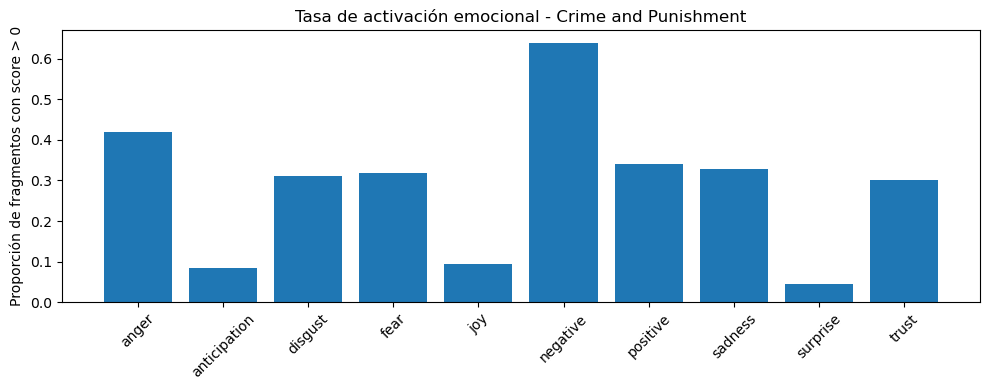

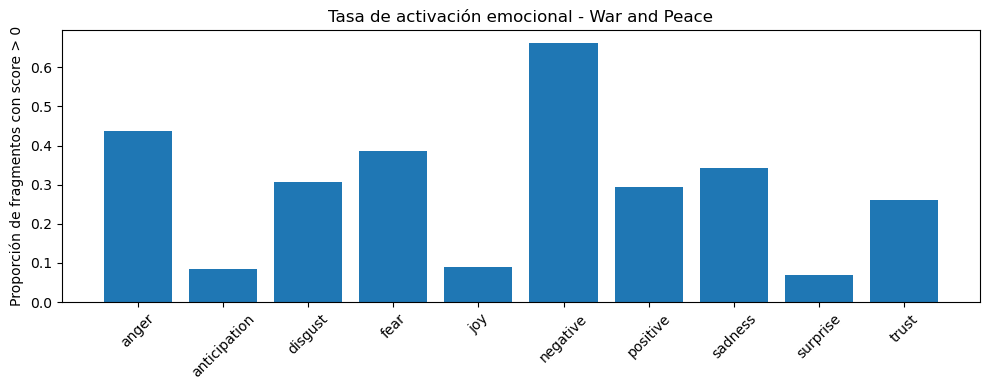

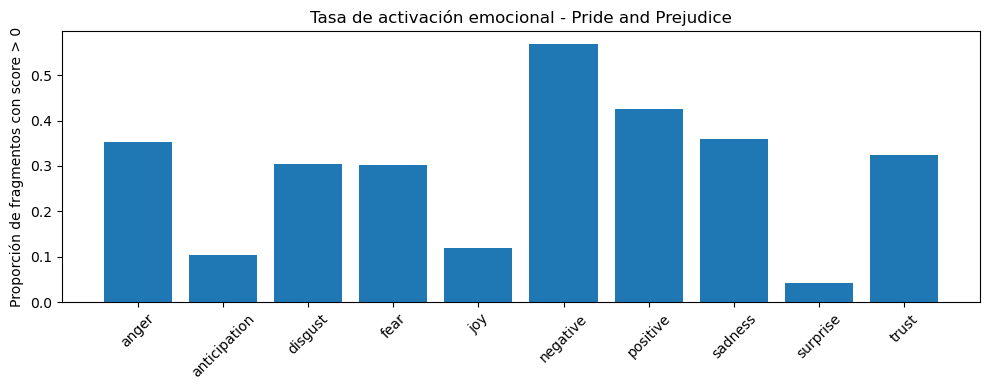

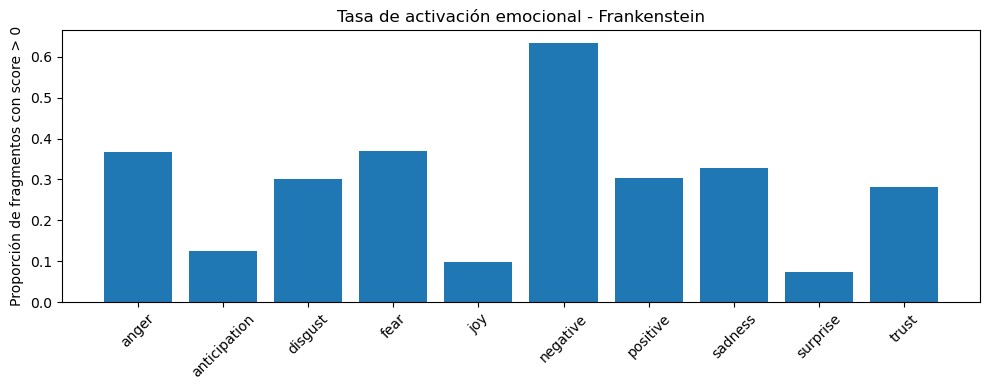

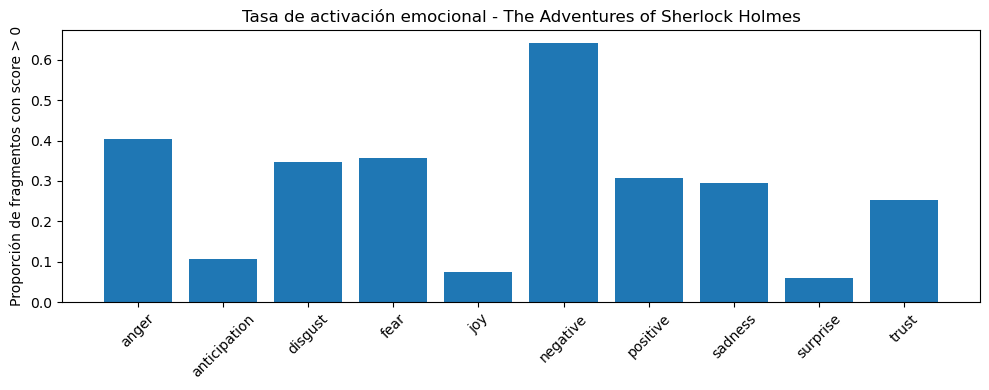

In [198]:
import matplotlib.pyplot as plt

for book, stats in books_stats.items():
    values = [stats["activation_rate"][emotion] for emotion in emotion_cols]

    plt.figure(figsize=(10, 4))
    plt.bar(emotion_cols, values)
    plt.title(f"Tasa de activación emocional - {book}")
    plt.ylabel("Proporción de fragmentos con score > 0")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

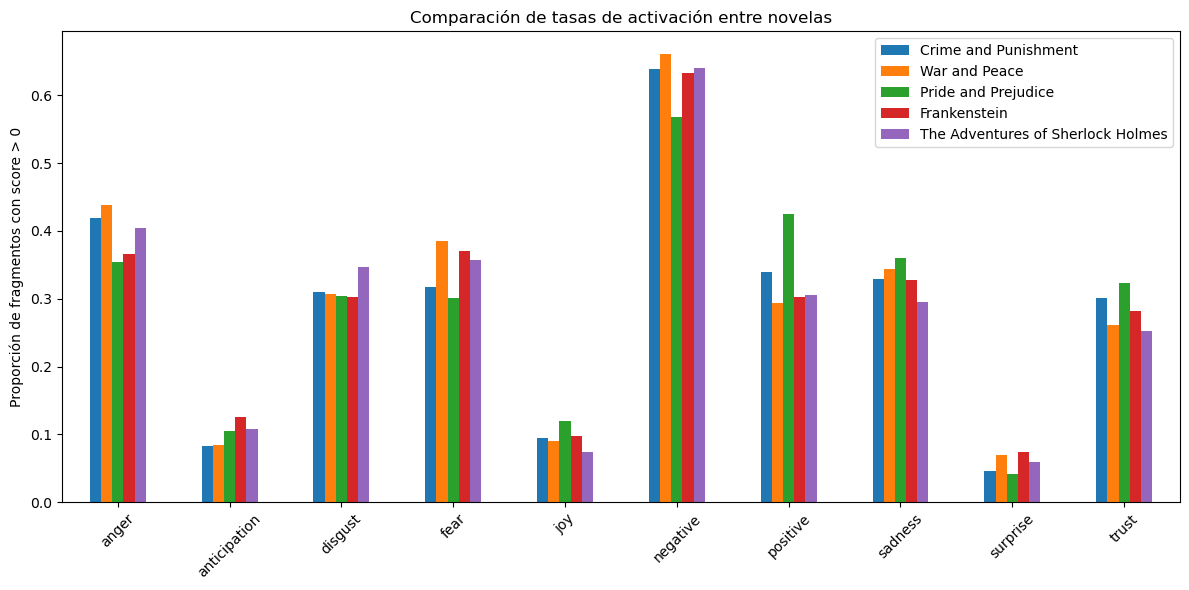

In [199]:
compare_plot_df = pd.DataFrame(
    {
        book: {emotion: stats["activation_rate"][emotion] for emotion in emotion_cols}
        for book, stats in books_stats.items()
    }
).T

compare_plot_df.T.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de tasas de activación entre novelas")
plt.ylabel("Proporción de fragmentos con score > 0")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Intensidad emociones

A continuación, se analiza la intensidad con la que se activan las emociones en aquellos fragmentos en los que efectivamente están presentes.

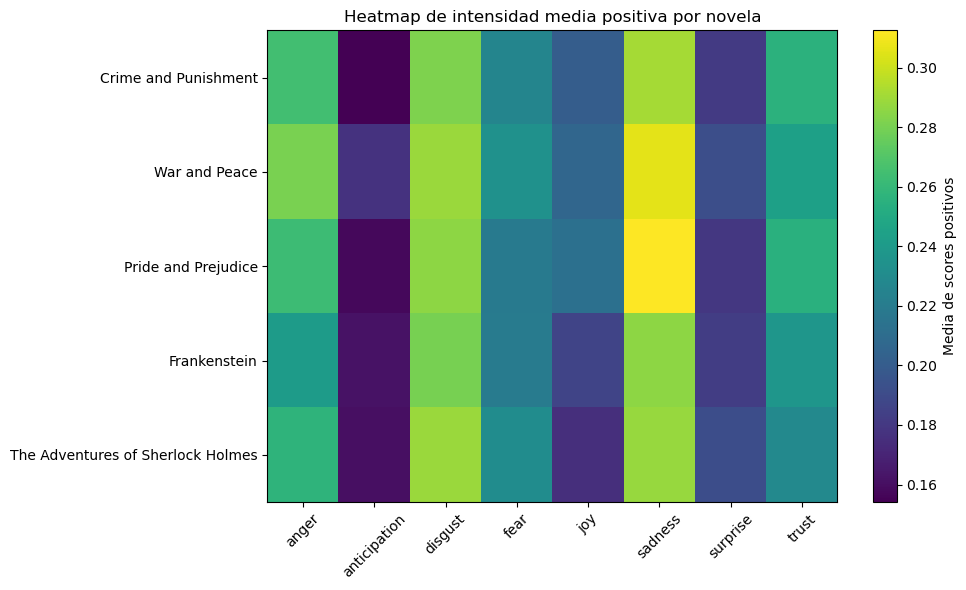

In [205]:
heatmap_df = pd.DataFrame({
    book: stats["mean_positive"]
    for book, stats in books_stats.items()
}).T[emotion_only_cols]

plt.figure(figsize=(10, 6))
plt.imshow(heatmap_df, aspect="auto")
plt.colorbar(label="Media de scores positivos")
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.title("Heatmap de intensidad media positiva por novela")
plt.tight_layout()
plt.show()

### Conclusiones

En las novelas analizadas se observa una predominancia de emociones vinculadas a un tono negativo. En particular,`anger`, `fear` y `sadness` aparecen entre las emociones con mayor tasa de activación en la mayoría de las obras, aunque con diferencias según cada caso. Así también cuando se activa `disgust` se activa con una intensidad considerable.

Este resultado parece razonable, ya que varias de estas novelas se articulan en torno a conflictos, situaciones de tensión y experiencias de sufrimiento o amenaza. En ese sentido, el modelo detecta un perfil emocional que, en términos generales, resulta consistente con el tono narrativo de los textos analizados.

### Evolución de emociones por novela

Para analizar la evolución emocional de cada novela a lo largo del texto, cada obra se dividió en 20 bloques consecutivos de tamaño similar. Sobre cada bloque se calculó la tasa de activación de cada emoción.

Esto permite observar cómo varía la presencia relativa de las emociones desde el inicio hasta el final de cada obra y detectar posibles cambios en el tono emocional a lo largo de la narración.

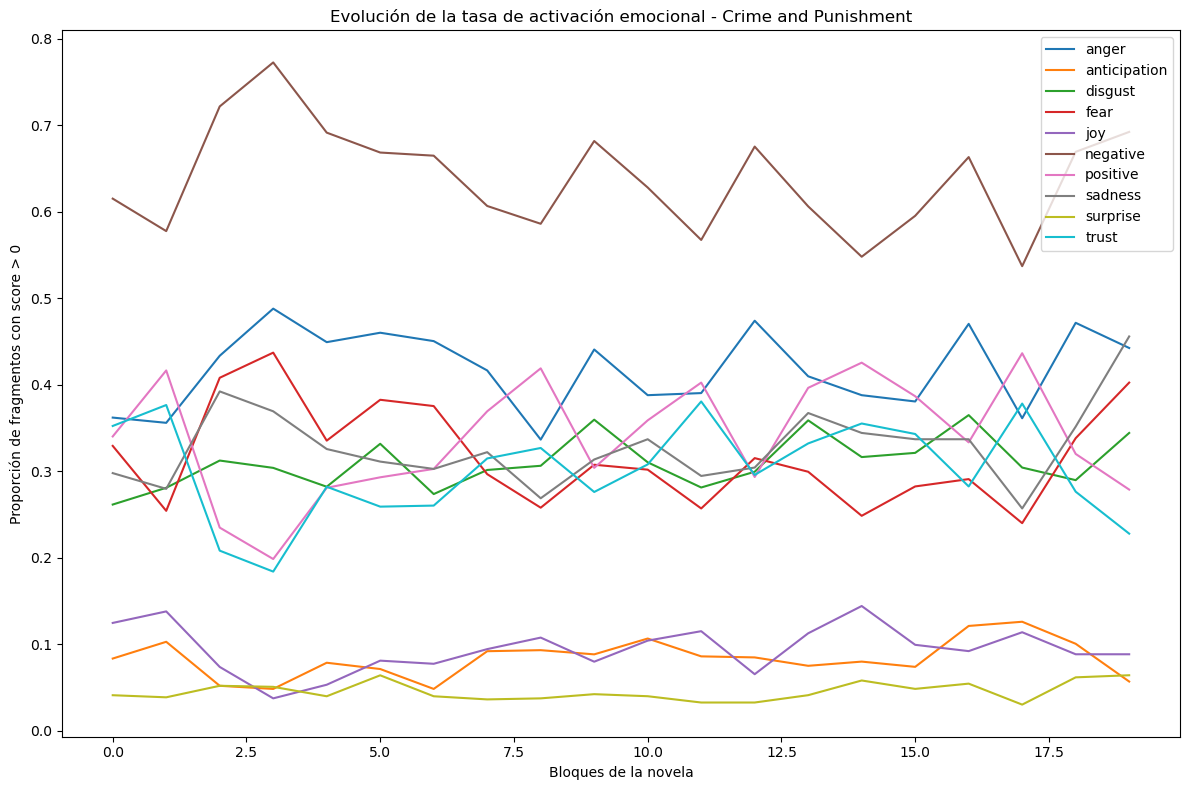

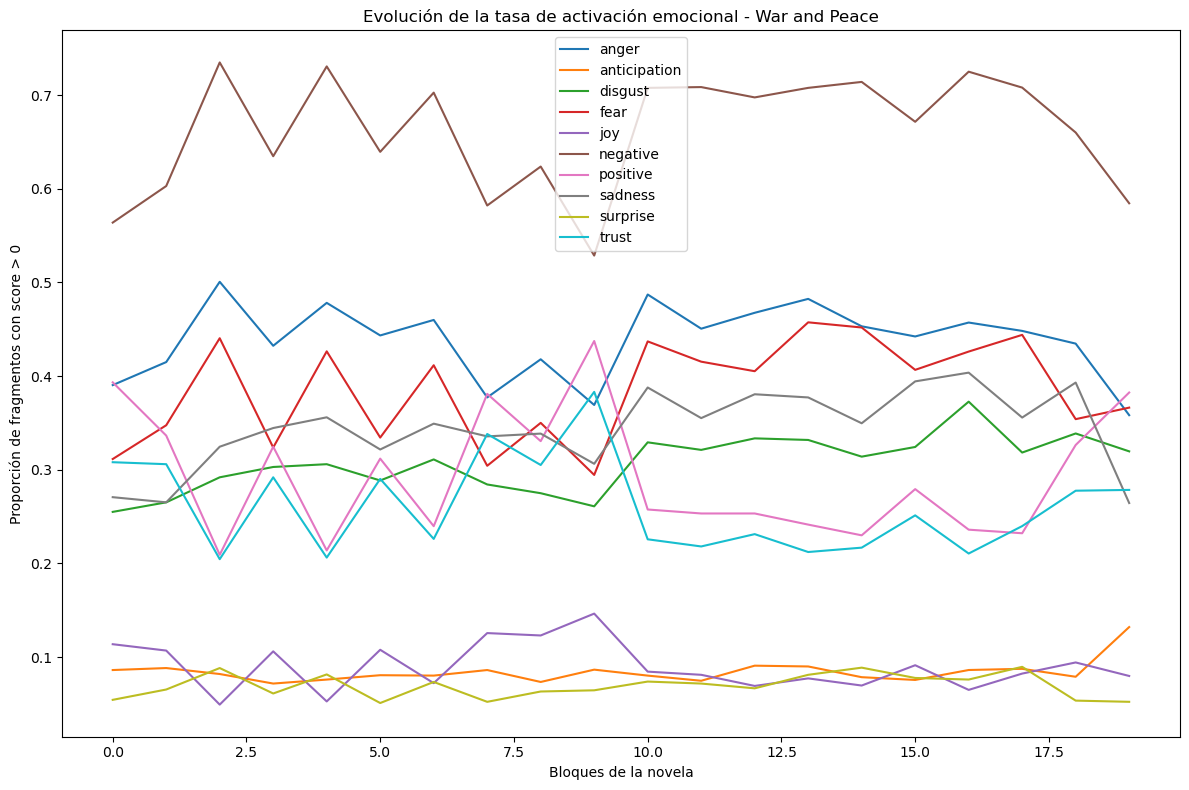

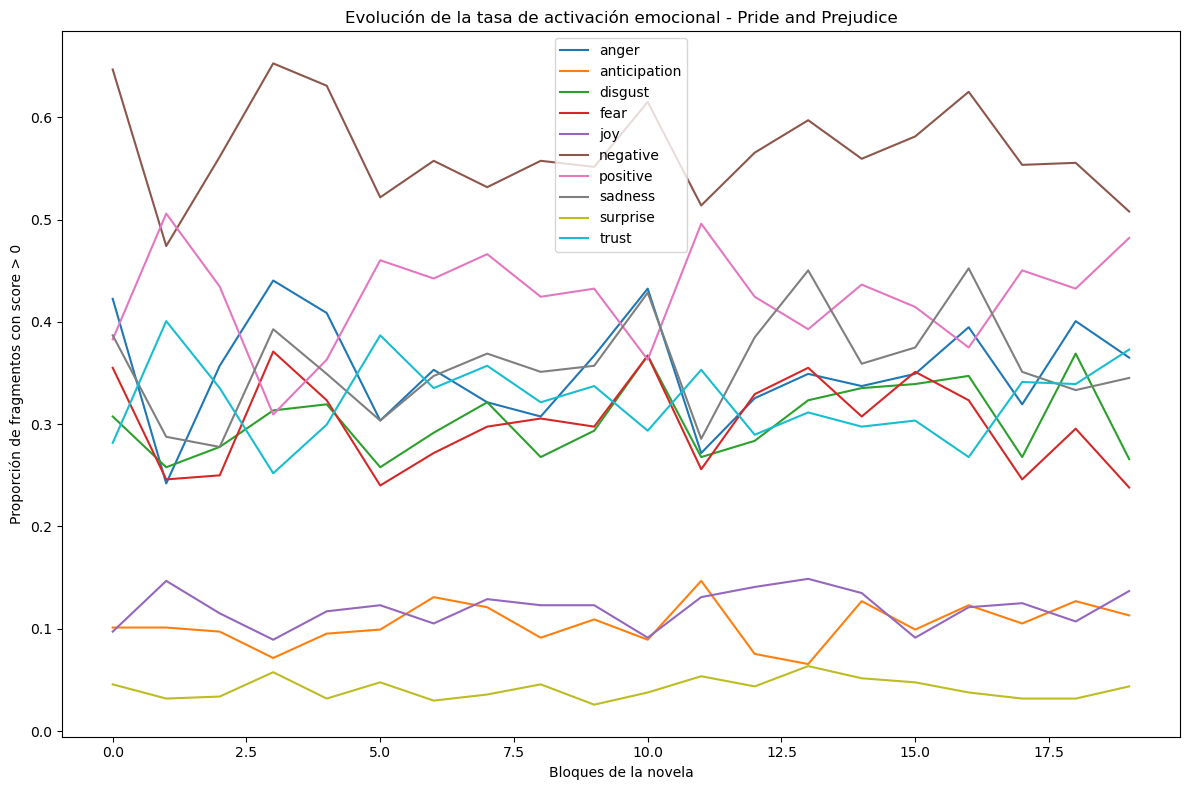

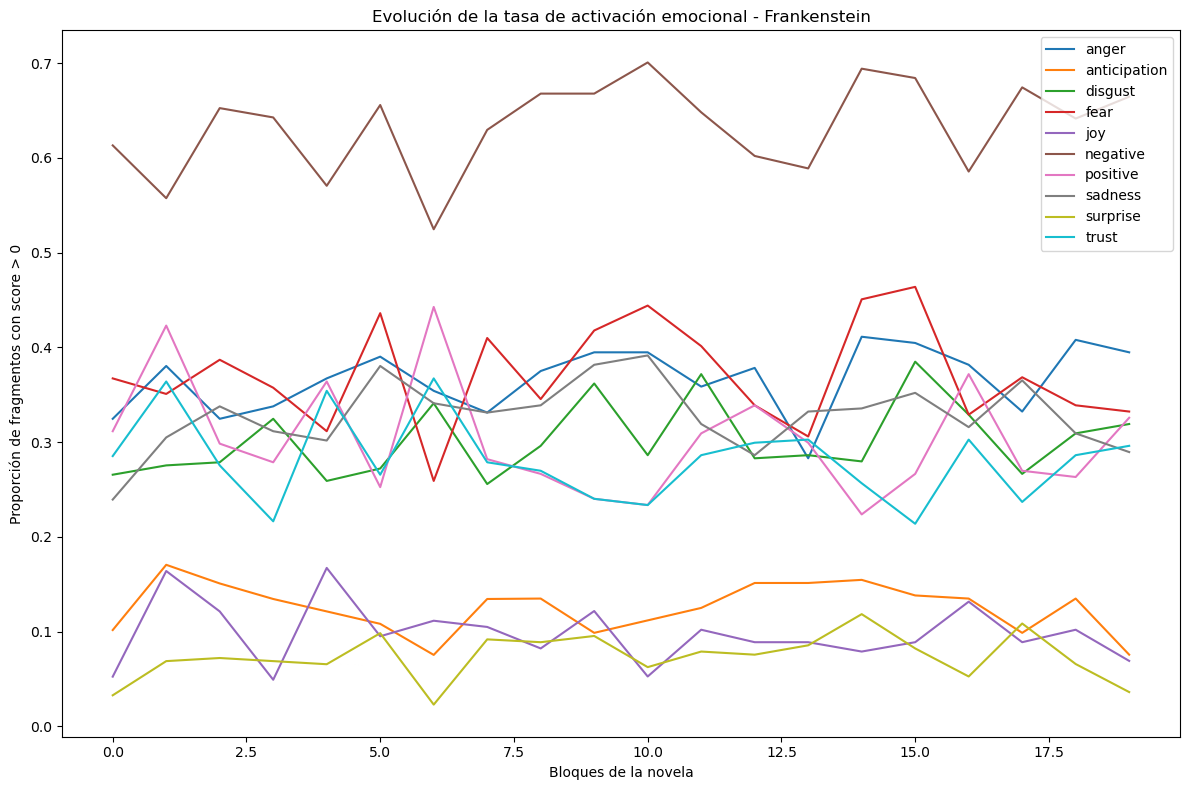

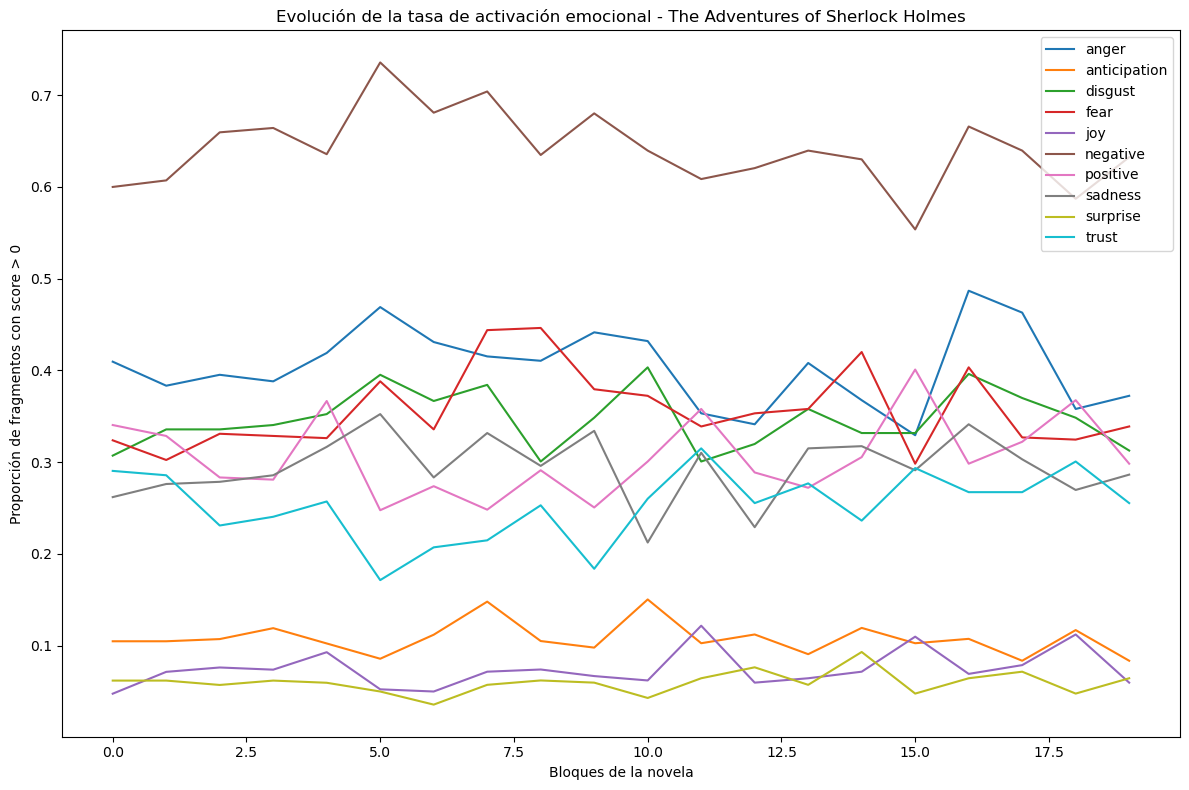

In [206]:
def get_block_activation_rates(matrix, n_blocks):
    blocks = np.array_split(matrix, n_blocks, axis=0)
    return np.array([
        (block > 0).mean(axis=0)
        for block in blocks
        if len(block) > 0
    ])

books_evolution = {
    book: get_block_activation_rates(
        np.array([[d[emotion] for emotion in emotion_cols] for d in emotion_dicts], dtype=float),
        n_blocks=20
    )
    for book, emotion_dicts in books_data.items()
}

for book_name, book_evolution in books_evolution.items():
    plt.figure(figsize=(12, 8))
    
    for i, emotion in enumerate(emotion_cols):
        plt.plot(book_evolution[:, i], label=emotion)

    plt.title(f"Evolución de la tasa de activación emocional - {book_name}")
    plt.xlabel("Bloques de la novela")
    plt.ylabel("Proporción de fragmentos con score > 0")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Conclusiones

Este gráfico no es tan fácil de leer, pero sí deja ver algunas tendencias generales. En ambas novelas, en la parte media suelen mantenerse altas varias emociones negativas, como `anger`, `fear` y `sadness`, lo cual tiene sentido porque esa zona suele concentrar buena parte del conflicto y la tensión narrativa.

En la parte final también se observan diferencias. En Crime and Punishment, el último bloque muestra más negatividad y menos positividad. En War and Peace, en cambio, el final parece menos negativo y algo más equilibrado. De todos modos, esto no alcanza para afirmar por sí solo que una novela tenga un final “feliz” o “triste”, sino solo para describir cómo cambian las emociones hacia el cierre.

### Fragmentos con mayor intensidad de emoción

Como parte final del análisis, se incluyen los fragmentos en los que cada emoción obtuvo las puntuaciones más altas. Para cada novela y para cada emoción específica, se seleccionaron los tres pasajes con mayor score. Esto permite complementar el análisis cuantitativo con ejemplos concretos y observar en qué partes del texto el modelo detecta una mayor intensidad emocional.

In [207]:
top_fragments = {}

for book, lines in analyzed_books.items():
    top_fragments[book] = {}

    for emotion in emotion_only_cols:
        ranked_idxs = sorted(
            range(len(lines)),
            key=lambda i: lines[i][emotion],
            reverse=True
        )[:3]

        top_fragments[book][emotion] = ranked_idxs

In [209]:
for book, emotions_dict in top_fragments.items():
    print(f"\nBOOK: {book}")

    for emotion, indices in emotions_dict.items():
        print(f"\n  Emotion: {emotion}")

        for idx in indices:
            print("   Text:", processed_books[book][idx])
            print("   Score:", analyzed_books[book][idx][emotion])
            print()


BOOK: Crime and Punishment

  Emotion: anger
   Text: His mother’s letter had been a torture to him, but as regards the chief
   Score: 1.5936319034048747

   Text: the night of his delirium when several times he had had the impulse to
   Score: 1.231046218553546

   Text: the cruelty of his words. (The significance of his reproaches and his
   Score: 1.2097000749210765


  Emotion: anticipation
   Text: garments I have on... and it’s the end of everything!”
   Score: 0.89353029358134

   Text: here--here you have the end of the world, an anchorage, a quiet haven,
   Score: 0.8284141619667545

   Text: be the end of it!”
   Score: 0.8231885174484012


  Emotion: disgust
   Text: that...” Luzhin muttered, “that ought to be before the police... though
   Score: 1.6979747222758566

   Text:  Razumihin insisted. “Nastasya, don’t be bashful, but help me--that’s
   Score: 1.5902743040062326

   Text: thought that Svidrigaïlov was dogging his footsteps. Svidrigaïlov had
   Score: 1.482435175

### Conclusiones

En varios casos se puede ver cierta relación entre el contenido del fragmento y la emoción detectada. Los pasajes que hablan de conflicto, dolor, amenaza o tensión suelen aparecer con puntuaciones altas en emociones como anger, fear o sadness, lo que indica que el modelo logra captar parte de la carga emocional del texto.

Sin embargo, también se notan fallos. Hay fragmentos en los que la emoción asignada no parece encajar del todo con el contenido, o en los que haría falta más contexto para entender por qué el modelo dio esa puntuación. Esto sugiere que el resultado no depende solo del sentido general del pasaje, sino también de palabras concretas, del estilo del texto y de cómo fue dividido en fragmentos. Además, en textos literarios pueden aparecer matices como ironía, ambigüedad o emociones expresadas de forma indirecta, que este tipo de enfoque no siempre logra captar bien.

También debe tenerse en cuenta que el preprocesado aplicado fue bastante general y no necesariamente se ajusta de la mejor manera a todas las obras. Al trabajar con textos literarios de estilos muy distintos, puede ocurrir que algunos fragmentos queden mal segmentados o pierdan parte de su sentido al ser aislados. Idealmente, cada tipo de texto debería contar con un preprocesado más adaptado a sus características, ya que no es lo mismo analizar una novela dialogada, una obra más descriptiva o un texto con un estilo más lírico.

Por otro lado, como el modelo fue entrenado con datos sintéticos y utiliza métodos de ML no neuronales con representaciones estáticas del texto, no se puede asumir que analice con precisión todos los matices de novelas clásicas. Por eso, aunque el análisis sirve para detectar tendencias generales y encontrar fragmentos interesantes, los resultados deben interpretarse con cautela y no como una lectura definitiva de la emoción en la obra.

## Discusión